# 3 · Potential fields

Attractive and repulsive potentials, steepest descent and its local minima, and the wave-front planner that
has none.

In [1]:
# Installs the module when it is missing (e.g. on Colab); a local `pip install -e .` is used as is.
import importlib.util

if importlib.util.find_spec("motion_planning") is None:
    %pip install -q git+https://github.com/Rudip1/learn-motion-planning

## Recap

Theory: [`1_theory/03_potential_fields.md`](../../1_theory/03_potential_fields.md).

- Attractive potential (3.1): quadratic $\tfrac12\zeta d^2$ up to $d^*$, conic beyond; gradient (3.2).
- Repulsive potential (3.3): $\tfrac12\eta(1/D - 1/Q^*)^2$ within the influence distance $Q^*$, with $D$ the
  distance transform of chapter 2. Total $U = U_\text{att} + U_\text{rep}$ (3.4).
- Steepest descent stops where $\nabla U = 0$ — at the goal or at a local minimum, which geometry can force.
- The wave-front (3.6) is a breadth-first wave from the goal through free cells; every cell but the goal has a
  lower neighbour, so descent always reaches the goal, along a shortest grid path.

In [2]:
from collections import deque

import matplotlib.pyplot as plt
import numpy as np

import motion_planning as mp
from motion_planning import maps
from motion_planning.plotting import INK, SERIES, show_grid, use_style

use_style()


def cells_to_xy(grid, cells):
    return np.array([grid.cell_center(tuple(c)) for c in cells])

## The two potentials

### ✏️ Exercise 1 — the attractive potential

Implement eq. (3.1) for an array of points `P` of shape (N, 2). The assert compares with the C++ version and
checks continuity at $d^*$.

In [3]:
def attractive(P, goal, zeta, d_star):
    d = np.linalg.norm(np.asarray(P) - goal, axis=-1)
    return np.where(d <= d_star, 0.5 * zeta * d**2, d_star * zeta * d - 0.5 * zeta * d_star**2)

In [4]:
rng = np.random.default_rng(3)
k = mp.PotentialParams(zeta=1.5, d_star=2.0, eta=1.0, q_star=1.0)
goal = np.array([1.0, 2.0])
P = rng.uniform(-5, 5, (200, 2))
assert np.allclose(attractive(P, goal, k.zeta, k.d_star), [mp.attractive_potential(p, goal, k) for p in P])
u = np.array([[0.6, 0.8]])
assert np.isclose(attractive(goal + (2 - 1e-9) * u, goal, 1.5, 2.0), attractive(goal + (2 + 1e-9) * u, goal, 1.5, 2.0))
print("✓ attractive potential")

✓ attractive potential


### ✏️ Exercise 2 — the repulsive potential from the distance transform

Implement eq. (3.3) for an array of clearances `D` (metres, possibly 0). Return `np.inf` where `D == 0`.

In [5]:
def repulsive(D, eta, q_star):
    D = np.asarray(D, dtype=float)
    with np.errstate(divide="ignore"):
        inv = 1.0 / D
    return np.where(D > q_star, 0.0, np.where(D == 0, np.inf, 0.5 * eta * (inv - 1.0 / q_star) ** 2))

In [6]:
grid = maps.trap()
edt = mp.distance_transform(grid)
assert np.allclose(repulsive(edt, k.eta, k.q_star), mp.repulsive_field(grid, k))
print("✓ repulsive potential")

✓ repulsive potential


## Descent and the trap

### ✏️ Exercise 3 — discrete steepest descent

Implement the algorithm of section 3.3 on a field array (rows = $y$): from `start = (x, y)`, move to the
8-neighbour with the lowest value while it is strictly lower. Return the list of visited cells. Compare with
`mp.descend`.

In [7]:
def descend(field, start):
    h, w = field.shape
    path = [tuple(start)]
    while True:
        x, y = path[-1]
        best = (x, y)
        for dx, dy in ((1, 0), (0, 1), (-1, 0), (0, -1), (1, 1), (-1, 1), (-1, -1), (1, -1)):
            nx, ny = x + dx, y + dy
            if 0 <= nx < w and 0 <= ny < h and field[ny, nx] < field[best[1], best[0]]:
                best = (nx, ny)
        if best == (x, y):
            return path
        path.append(best)

In [8]:
start_xy, goal_xy = np.array([1.0, 3.0]), np.array([6.5, 3.0])
start, goal = tuple(grid.world_to_cell(start_xy)), tuple(grid.world_to_cell(goal_xy))
U = mp.total_field(grid, grid.cell_center(goal), k)
mine = descend(U, start)
ref = mp.descend(U, start, goal)
assert np.array_equal(np.array(mine), ref.path)
print(f"✓ descent; reached goal: {ref.reached_goal}, stuck in a local minimum: {ref.local_minimum}")

✓ descent; reached goal: False, stuck in a local minimum: True


### 🔨 Break it — the U-shaped trap

From the left the robot is pulled into the U and stopped by its back wall. Try every gain you like in the cell
below: the local minimum stays. Starting from below the trap, the same field works.

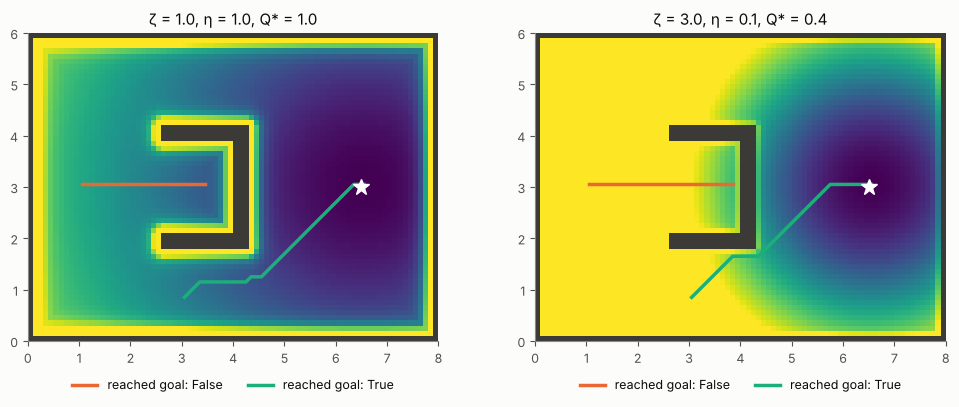

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (zeta, eta, q_star) in zip(axes, [(1.0, 1.0, 1.0), (3.0, 0.1, 0.4)]):
    kk = mp.PotentialParams(zeta=zeta, d_star=2.0, eta=eta, q_star=q_star)
    Ui = mp.total_field(grid, grid.cell_center(goal), kk)
    show_grid(ax, grid, field=np.minimum(Ui, 15), cmap="viridis")
    for s, c in [(start_xy, SERIES[1]), (np.array([3.0, 0.8]), SERIES[2])]:
        r = mp.descend(Ui, grid.world_to_cell(s), goal)
        xy = cells_to_xy(grid, r.path)
        ax.plot(xy[:, 0], xy[:, 1], color=c, lw=2.5, label=f"reached goal: {r.reached_goal}")
    ax.plot(*goal_xy, "*", color="white", ms=12)
    ax.set_title(f"ζ = {zeta}, η = {eta}, Q* = {q_star}")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=2)
plt.show()

### 🔨 Break it — gains that close a door or move the goal

In the rooms map, drive straight down through a 1 m door to a goal 0.6 m above a table.
- With a large influence distance $Q^*$ the door frames' repulsion fills the doorway: the robot stops above it.
- With a moderate $Q^*$ the robot passes the door, but the table's repulsion moves the minimum of $U$ off the
  goal: the robot stops next to it.

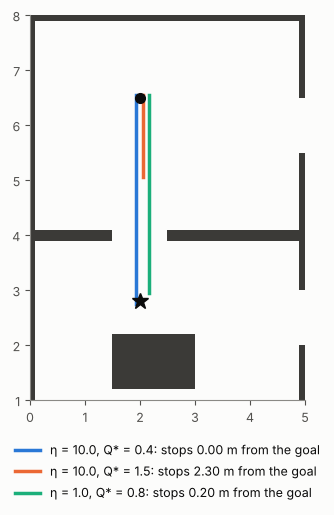

In [10]:
rooms = maps.rooms()
s_xy, g_xy = np.array([2.0, 6.5]), np.array([2.0, 2.8])
s, g = rooms.world_to_cell(s_xy), rooms.world_to_cell(g_xy)
fig, ax = plt.subplots(figsize=(6, 5))
show_grid(ax, rooms)
for (eta, q_star), c in zip([(10.0, 0.4), (10.0, 1.5), (1.0, 0.8)], SERIES):
    r = mp.descend(mp.total_field(rooms, rooms.cell_center(g), mp.PotentialParams(1.0, 2.0, eta, q_star)), s, g)
    xy = cells_to_xy(rooms, r.path)
    end = np.linalg.norm(xy[-1] - rooms.cell_center(g))
    offset = 0.12 * (SERIES.index(c) - 1)  # side by side, so the three paths stay visible
    ax.plot(xy[:, 0] + offset, xy[:, 1], color=c, lw=2.5,
            label=f"η = {eta}, Q* = {q_star}: stops {end:.2f} m from the goal")
ax.plot(*s_xy, "o", color=INK)
ax.plot(*g_xy, "*", color=INK, ms=12)
ax.set_xlim(0, 5)
ax.set_ylim(1, 8)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08))
plt.show()

## The wave-front planner

### ✏️ Exercise 4 — the wave-front

Implement eq. (3.6) with 4-connectivity: a breadth-first wave from `goal = (x, y)` through free cells of the
occupancy array `occ`. Return an array of step counts with `np.inf` on obstacles and unreachable cells.

In [11]:
def wavefront(occ, goal):
    h, w = occ.shape
    W = np.full((h, w), np.inf)
    W[goal[1], goal[0]] = 0
    queue = deque([goal])
    while queue:
        x, y = queue.popleft()
        for dx, dy in ((1, 0), (0, 1), (-1, 0), (0, -1)):
            nx, ny = x + dx, y + dy
            if 0 <= nx < w and 0 <= ny < h and not occ[ny, nx] and W[ny, nx] == np.inf:
                W[ny, nx] = W[y, x] + 1
                queue.append((nx, ny))
    return W

In [12]:
example = np.array([[0, 0, 0, 0], [0, 1, 1, 0], [0, 0, 0, 0]], dtype=np.uint8)  # rows y = 0, 1, 2
assert np.array_equal(wavefront(example, (0, 0)), [[0, 1, 2, 3], [1, np.inf, np.inf, 4], [2, 3, 4, 5]])
assert np.array_equal(wavefront(grid.to_array(), goal), mp.wavefront(grid, goal, mp.Connectivity.Four))
print("✓ wave-front")

✓ wave-front


The wave-front escapes the trap, and in the rooms map it finds the way through the doors. Its paths have
zero clearance; descending the wave-front of the *inflated* grid (chapter 2) keeps the robot off the walls.

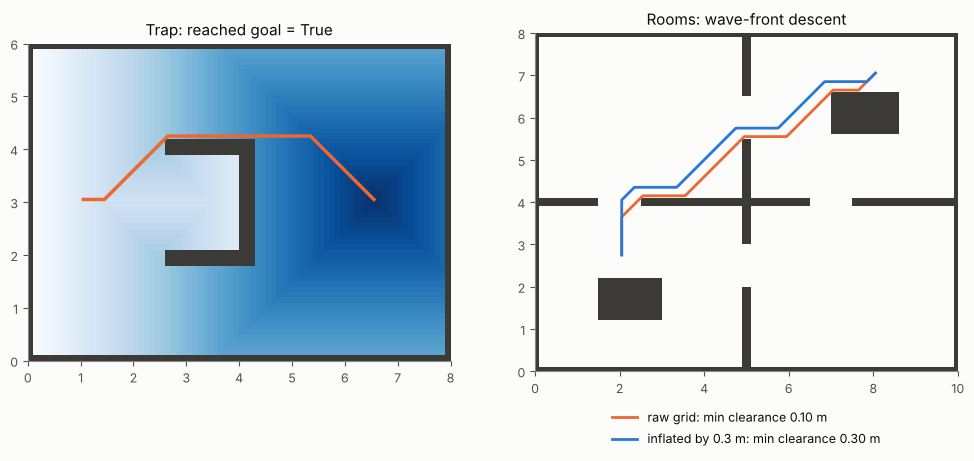

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
r = mp.descend(mp.wavefront(grid, goal, mp.Connectivity.Eight), start, goal)
show_grid(axes[0], grid, field=mp.wavefront(grid, goal, mp.Connectivity.Eight), cmap="Blues_r")
xy = cells_to_xy(grid, r.path)
axes[0].plot(xy[:, 0], xy[:, 1], color=SERIES[1], lw=2.5)
axes[0].set_title(f"Trap: reached goal = {r.reached_goal}")

s2, g2 = rooms.world_to_cell([2.0, 2.8]), rooms.world_to_cell([8.0, 7.0])
show_grid(axes[1], rooms)
for occ_grid, label, c in [(rooms, "raw grid", SERIES[1]), (mp.inflate(rooms, 0.3), "inflated by 0.3 m", SERIES[0])]:
    rr = mp.descend(mp.wavefront(occ_grid, g2, mp.Connectivity.Eight), s2, g2)
    xy = cells_to_xy(rooms, rr.path)
    clearance = min(mp.distance_transform(rooms)[y, x] for x, y in rr.path)
    axes[1].plot(xy[:, 0], xy[:, 1], color=c, lw=2, label=f"{label}: min clearance {clearance:.2f} m")
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.08))
axes[1].set_title("Rooms: wave-front descent")
plt.show()

### 🔨 Break it — an unreachable goal

Close the door of the goal room. The wave-front never reaches the start: its value there is $\infty$, which is
a proof (at this resolution) that no path exists. A potential field would simply stop somewhere.

In [14]:
closed = rooms.to_array().copy()
closed[55:66, 49:52] = 1  # wall up the door at x = 5 m, y = 5.5-6.5 m
closed[39:42, 65:76] = 1  # and the door at y = 4 m, x = 6.5-7.5 m
closed_grid = mp.OccupancyGrid(closed, rooms.resolution)
w_closed = mp.wavefront(closed_grid, g2, mp.Connectivity.Eight)
print("wave-front value at the start:", w_closed[s2.y, s2.x])
print("reachable free cells:", int(np.isfinite(w_closed).sum()), "of", int((closed == 0).sum()))

wave-front value at the start: inf
reachable free cells: 1642 of 7004


## What to remember

- Potential fields are local: cheap, smooth, and stuck wherever the attraction and repulsion balance.
- Local minima come from geometry; no gain tuning removes them. Large $Q^*$ also closes doors and displaces goals.
- The wave-front is brushfire from the goal through free space; it has no local minima, gives shortest grid
  paths, and proves unreachability.
- Shortest-in-steps paths graze obstacles: plan on the inflated grid or add a clearance cost.